<a href="https://colab.research.google.com/github/orcasandpandas/Data-Science-Cohort-20/blob/main/Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1: Transaction Success Prediction

**Deep Dive Coding Data Science Bootcamp Project 1**

---
Victor Huang - March 9, 2026

## Problem Definition


The objective of this project is to utilize past transaction data in order to predict whether or not a future customer will make a transaction.  As we are trying to predict whether or not a customer will make a transaction, this is a supervised binary classification problem.  The machine learning model utilized will be Gaussian Native Bayes classification.

## Data Collection/Sources


### Data Overview

The data will be accessed from AWS, and all columns will be anonymized to facilitate unbiased consideration.

https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv


### Imports

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn import preprocessing
from sklearn import metrics
from sklearn.model_selection import train_test_split



url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv"

df = pd.read_csv(url)
df

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We can load the URL and observe that there are a large number of variables, with many NaN values.  Pandas will help us with processing the data, numpy is great for working with arrays or linear algebra, matplotlib is good for precise plots and seaborn is good for quickly making plots when less precision is needed.  sklearn is needed for the modelling

### Heads and tails check

```
# This is formatted as code
```




In [ ]:
df.head()


,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.tail()

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049999,1049999,train_1049999,0.0,2.1828,12.3805,17.5654,NaN,8.1795,NaN,NaN,...,NaN,-12.1108,NaN,10.7608,NaN,NaN,NaN,NaN,NaN,14.1690


By looking at the head and tail, we verify that there are no extraneous columns at the top and no extraneous calculations at the bottom.  The second column appears to be redundant as it just restates the index

### Info and summary statistics

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050000 entries, 0 to 1049999
Columns: 104 entries, Unnamed: 0 to var_100
dtypes: float64(102), int64(1), object(1)
memory usage: 833.1+ MB


df.info() shows us the datatypes, where we the the data is largely composed of floats with just one int (likely the unnamed columns) and one object (likely ID_code)

In [ ]:
df.describe()

,Unnamed: 0,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
count,1.050000e+06,180000.000000,180000.000000,180000.000000,180000.000000,0.0,180000.000000,0.0,0.0,180000.000000,...,0.0,180000.000000,0.0,180000.000000,0.0,0.0,0.0,0.0,0.0,180000.000000
mean,5.249995e+05,0.100222,7.440715,15.870166,12.735619,NaN,-0.668334,NaN,NaN,1.190419,...,NaN,-3.294620,NaN,-6.727860,NaN,NaN,NaN,NaN,NaN,14.224538
std,3.031090e+05,0.300297,3.021636,3.010492,4.185923,NaN,5.968300,NaN,NaN,5.169343,...,NaN,7.418545,NaN,8.278554,NaN,NaN,NaN,NaN,NaN,0.171058
min,0.000000e+00,0.000000,-2.691700,6.299300,-1.018500,NaN,-22.748700,NaN,NaN,-15.194000,...,NaN,-29.984000,NaN,-35.211700,NaN,NaN,NaN,NaN,NaN,13.729000
25%,2.624998e+05,0.000000,5.160325,13.830400,9.664675,NaN,-4.997500,NaN,NaN,-2.571400,...,NaN,-8.757925,NaN,-12.835875,NaN,NaN,NaN,NaN,NaN,14.098900
50%,5.249995e+05,0.000000,7.350950,15.934600,12.670700,NaN,-0.560300,NaN,NaN,1.194600,...,NaN,-3.170950,NaN,-6.615100,NaN,NaN,NaN,NaN,NaN,14.226800
75%,7.874992e+05,0.000000,9.511125,18.061425,15.837300,NaN,3.632525,NaN,NaN,5.090450,...,NaN,2.043350,NaN,-0.885250,NaN,NaN,NaN,NaN,NaN,14.361800
max,1.049999e+06,1.000000,16.716500,26.079100,26.997600,NaN,18.855400,NaN,NaN,18.471400,...,NaN,21.236400,NaN,18.105600,NaN,NaN,NaN,NaN,NaN,14.743000


df.describe() tells us that many variables are all made of nulls, and target is indeed a binary value.  We can look into this later

### Analyzing the composition of the data set

In [ ]:
df.isna().sum().sort_values(ascending=False)*100/len(df)


,0
var_3,100.000000
var_16,100.000000
var_12,100.000000
var_11,100.000000
var_9,100.000000
...,...
var_88,82.857143
var_94,82.857143
var_100,82.857143
Unnamed: 0,0.000000


Here we see the percentage of null values in each variable, and find that many are 100%!  In fact, the lowest percentage of null values is still quite high at 82.85%, and the value is the same across several variables.  The only variables without null is the Unnamed one and the ID_code

In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
var_3,1050000
var_16,1050000
var_12,1050000
var_11,1050000
var_9,1050000
...,...
var_88,870000
var_94,870000
var_100,870000
Unnamed: 0,0


This code is similar to the one above, but instead shows us the count of null values per variable.  The lowest count is 870000 accross several variables suggesting that 870000 rows are entirely made up of null data.

In [ ]:
df.nunique().sort_values( ascending = False )

,0
Unnamed: 0,1050000
ID_code,1050000
var_52,137280
var_86,134537
var_94,131746
...,...
var_93,0
var_96,0
var_97,0
var_98,0


As suspected, the unnamed column and ID_code columns are redundant and can be dropped later.  We also see many columns with 0 unique values which are likely all nulls

In [ ]:
df["target"].value_counts( dropna= False)


,count
target,
NaN,870000
0.0,161960
1.0,18040


The amount of null values is 870000 and is exactly inline with other variables, suggesting that 870000 lines are completely redundant.  We also see that the only non-null values are 0 and 1, which is excellent.  It should be noted the FAR more unsuccessful transactions are shown

## Data Cleaning


Before we can work with the data, we need to make sure it is as high quality as possible, since things such as missing values will be restrictive to our training

### Removing unique identifiers

Unique identifiers are columns that are essentially the same as an ID and are typically redundant since the ID serves the same purpose.  They can be identified by having as many values as there are rows.

In [ ]:
df_bak01 = df.copy()

In [ ]:
df.drop(columns = ["Unnamed: 0", "ID_code"], axis = "columns", inplace = True)
df

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,-1.9254,6.4760,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,-6.8112,7.3226,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,1.6614,6.1486,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Lets drop the column of Unnamed: 0 since we saw earlier that it was redundant.  A backup has been made of the original data in df_bak01 in case we need to restore it

### Removing null values

Some values are just completely blank, which will almost certainly not be good for our

print(pd.__version__)

In [ ]:
df_bak02 = df.copy()

In [ ]:
df = df.dropna(axis = 1, how = "all")
df

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,2.8817,11.6975,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049995,1.0,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,2.4579,14.7175,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,0.0,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,2.5439,10.2936,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689
1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


All variables were 100% nulls have been dropped!  The how = "all" parameter in dropna indicates that the column is only dropped if every single value is null

In [ ]:
df.isna().sum().sort_values(ascending=False)*100/len(df)


,0
target,82.857143
var_0,82.857143
var_1,82.857143
var_2,82.857143
var_4,82.857143
var_7,82.857143
var_8,82.857143
var_14,82.857143
var_15,82.857143
var_17,82.857143


All rows where target is NaN are a safe bet to drop, since target has the same proportion of null values and any row where the target value is null is unusable for further analysis

In [ ]:
df = df.dropna(subset=['target'])
df

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,2.8817,11.6975,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,0.0,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,2.2225,7.2218,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,0.0,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,3.4990,4.2892,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,0.0,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,2.8910,8.2374,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,0.0,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,3.2771,12.6446,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,0.0,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,3.0732,11.0135,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,0.0,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,2.4057,18.2729,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049995,1.0,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,2.4579,14.7175,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049997,0.0,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,2.5439,10.2936,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


The subset parameter makes it so all rows where target specifically is null are dropped

In [ ]:
df.isna().sum().sort_values(ascending=False)*100/len(df)


,0
target,0.0
var_0,0.0
var_1,0.0
var_2,0.0
var_4,0.0
var_7,0.0
var_8,0.0
var_14,0.0
var_15,0.0
var_17,0.0


No more nulls!

### Checking for duplicates

In [ ]:
# .duplicated() gives a series of rows with duplicates, which we can use to make a mask
df_duplicates = df[df.duplicated()]
# df_duplicates will only have rows with duplicates
df_duplicates

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100


There are no duplicates!

## Exploratory Data Analysis


Time to explore the data!  We can look at the aspects such as distributions of the variables to decide on what to do moving forward

### Checking distributions

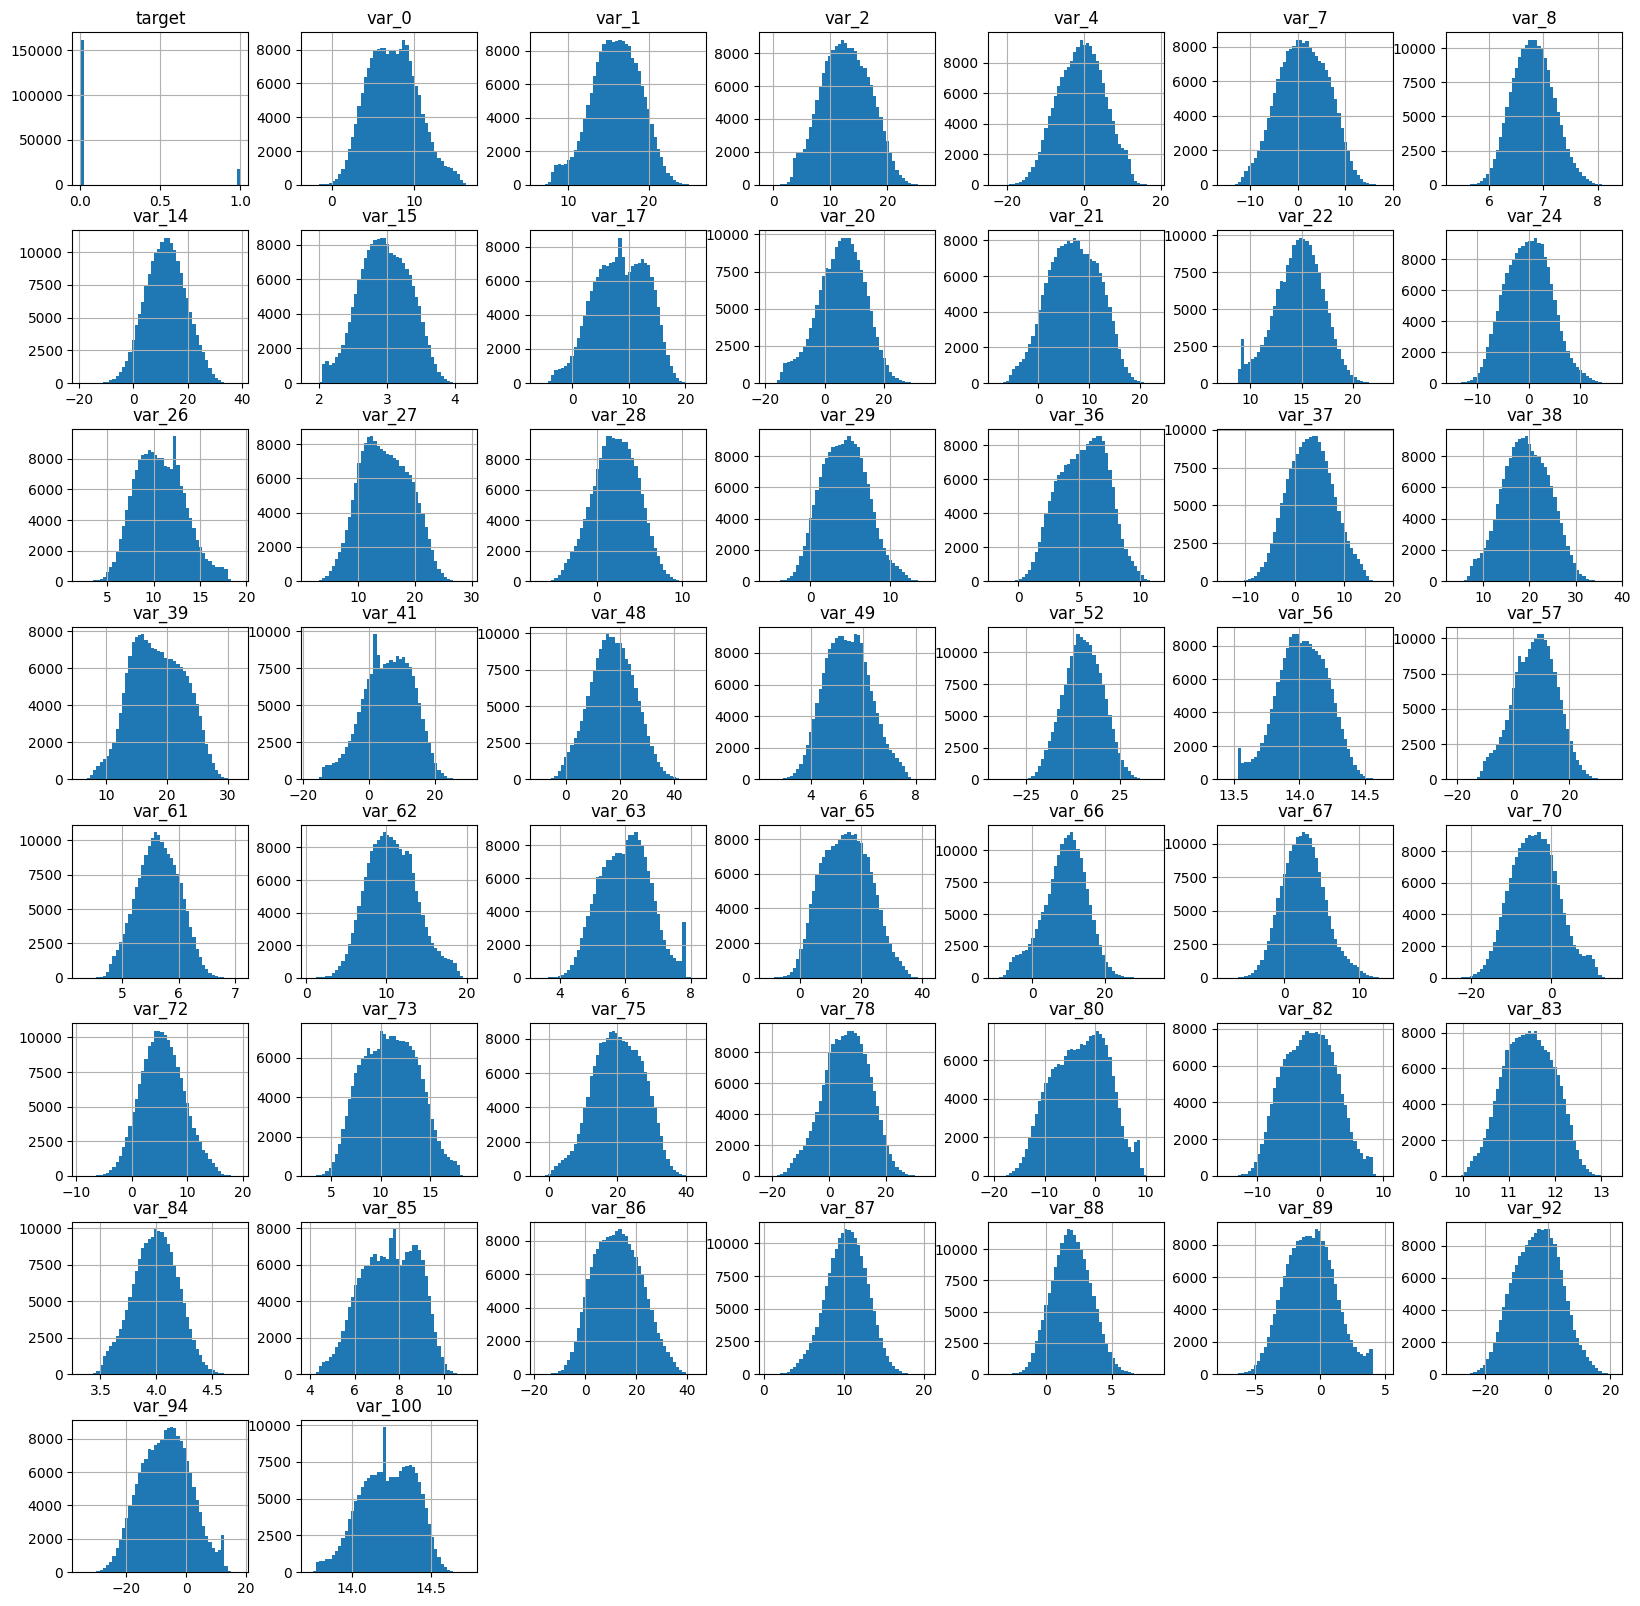

In [ ]:
# Lets use histograms to look at the distributions of our data!  We need to set the figsize and amount of bins otherwise our graphs will look strange.  Lets focus on predictors for now.
df.hist(figsize=(20, 20), bins=50)
plt.show()

If we make a histogram of all our variables, we see that everything seems pretty normally distributed!  May not be a bad idea to double check var 100, though.

In [ ]:
# This shows us the 10 most frequent values
df['var_100'].value_counts().head(10)

,count
var_100,
14.1999,276
14.2000,259
14.2003,232
14.1997,231
14.2002,228
14.1996,224
14.1998,224
14.2001,214
14.2004,208


Seems there is nothing wrong with var 100!  We can move on

### Correlation Checking

In [ ]:
# Lets make sure none of the predictors are redundant!  The code below gets the correations of non target variables and their absolute values
pred_corr = df.drop("target", axis = 1).corr().abs()
pred_corr

,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,var_20,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
var_0,1.000000,0.000892,0.000225,0.000269,0.001320,0.002949,0.002901,0.007758,0.002799,0.001353,...,0.004960,0.005451,0.000716,0.004577,0.004664,0.001088,0.000236,0.001668,0.001837,0.001475
var_1,0.000892,1.000000,0.006064,0.000821,0.000783,0.007127,0.006180,0.002585,0.001663,0.001590,...,0.004265,0.002411,0.001484,0.003859,0.000485,0.003141,0.006188,0.000071,0.003682,0.003964
var_2,0.000225,0.006064,1.000000,0.003427,0.000108,0.001809,0.002786,0.001177,0.006360,0.004796,...,0.004890,0.002240,0.001980,0.001161,0.003921,0.002087,0.004422,0.003418,0.001565,0.002418
var_4,0.000269,0.000821,0.003427,1.000000,0.002750,0.003347,0.001377,0.004732,0.001814,0.000539,...,0.000657,0.005267,0.004266,0.004179,0.004211,0.002330,0.000254,0.001090,0.000468,0.002807
var_7,0.001320,0.000783,0.000108,0.002750,1.000000,0.003199,0.003588,0.002329,0.004282,0.001971,...,0.000412,0.003262,0.002574,0.001824,0.001186,0.002811,0.001306,0.000236,0.000568,0.004575
var_8,0.002949,0.007127,0.001809,0.003347,0.003199,1.000000,0.003472,0.003858,0.002727,0.003417,...,0.008394,0.004254,0.002446,0.001117,0.003713,0.003929,0.003837,0.003422,0.003204,0.000821
var_14,0.002901,0.006180,0.002786,0.001377,0.003588,0.003472,1.000000,0.007115,0.004249,0.001595,...,0.002214,0.002179,0.003054,0.000160,0.000504,0.004046,0.003136,0.005715,0.001501,0.000106
var_15,0.007758,0.002585,0.001177,0.004732,0.002329,0.003858,0.007115,1.000000,0.002467,0.003584,...,0.000581,0.006633,0.004569,0.001573,0.003251,0.003066,0.001541,0.003719,0.002825,0.004247
var_17,0.002799,0.001663,0.006360,0.001814,0.004282,0.002727,0.004249,0.002467,1.000000,0.001476,...,0.005578,0.001237,0.000210,0.002714,0.004149,0.002182,0.002642,0.001968,0.004100,0.000822
var_20,0.001353,0.001590,0.004796,0.000539,0.001971,0.003417,0.001595,0.003584,0.001476,1.000000,...,0.001476,0.003107,0.001610,0.001186,0.004265,0.001449,0.004506,0.003241,0.000988,0.001734


As you can see, corr() returns a 2d matrix where every pair of variables and their correlations are shown!  But you may notice half the matrix is redundant, since the pairs var_1,var_0 and var_0,var_1 are both shown despite having the exact same value.  Fortunately, theres a neat trick to help this.

In [ ]:
# Don't be intimidated by this line!  Essentially, it takes our predictors matrx
# and turns it into all true values through ones_like,
# then .triu turns that into a triangle.
tri_mask = np.triu(np.ones_like(pred_corr, dtype = bool), k=1)

What makes a triangular mask useful?  Well, when applied to a table of corretions, it will remove all duplicate pairs as well as self pairs.  Think of it as a knife cutting the square into two triangles and us keeping one slice.  Also, the mask is the upper triangle but the lower triangle would work the same.  Also, the k=1 parameter makes the triangle start one above the diagonal

In [ ]:
tri_corr = pred_corr.where(tri_mask)
tri_corr

,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,var_20,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
var_0,NaN,0.000892,0.000225,0.000269,0.001320,0.002949,0.002901,0.007758,0.002799,0.001353,...,0.004960,0.005451,0.000716,0.004577,0.004664,0.001088,0.000236,0.001668,0.001837,0.001475
var_1,NaN,NaN,0.006064,0.000821,0.000783,0.007127,0.006180,0.002585,0.001663,0.001590,...,0.004265,0.002411,0.001484,0.003859,0.000485,0.003141,0.006188,0.000071,0.003682,0.003964
var_2,NaN,NaN,NaN,0.003427,0.000108,0.001809,0.002786,0.001177,0.006360,0.004796,...,0.004890,0.002240,0.001980,0.001161,0.003921,0.002087,0.004422,0.003418,0.001565,0.002418
var_4,NaN,NaN,NaN,NaN,0.002750,0.003347,0.001377,0.004732,0.001814,0.000539,...,0.000657,0.005267,0.004266,0.004179,0.004211,0.002330,0.000254,0.001090,0.000468,0.002807
var_7,NaN,NaN,NaN,NaN,NaN,0.003199,0.003588,0.002329,0.004282,0.001971,...,0.000412,0.003262,0.002574,0.001824,0.001186,0.002811,0.001306,0.000236,0.000568,0.004575
var_8,NaN,NaN,NaN,NaN,NaN,NaN,0.003472,0.003858,0.002727,0.003417,...,0.008394,0.004254,0.002446,0.001117,0.003713,0.003929,0.003837,0.003422,0.003204,0.000821
var_14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007115,0.004249,0.001595,...,0.002214,0.002179,0.003054,0.000160,0.000504,0.004046,0.003136,0.005715,0.001501,0.000106
var_15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002467,0.003584,...,0.000581,0.006633,0.004569,0.001573,0.003251,0.003066,0.001541,0.003719,0.002825,0.004247
var_17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001476,...,0.005578,0.001237,0.000210,0.002714,0.004149,0.002182,0.002642,0.001968,0.004100,0.000822
var_20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.001476,0.003107,0.001610,0.001186,0.004265,0.001449,0.004506,0.003241,0.000988,0.001734


where() is a function that takes an array of booleans and makes it so True keeps the value while False replaces it.  Since tri_mask is the only parameter, values get replaced by NaN.  

In [ ]:
rank_corr = tri_corr.unstack().dropna().sort_values(ascending=False)
rank_corr


,,0
var_70,var_57,0.009935
var_84,var_63,0.009786
var_38,var_22,0.009728
var_87,var_61,0.009601
var_82,var_41,0.009469
...,...,...
var_89,var_73,0.000028
var_83,var_27,0.000021
var_75,var_36,0.000019
var_24,var_15,0.000018


Nice!  No redundancies to worry about.

### Separating successful and unsuccessful transactions

In [ ]:
# Here we just use a filter and copy it to our new frames!
succ_trans = df[df['target'] == 1].copy()
succ_trans


,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
57,1.0,8.9078,12.1321,9.4707,-5.8102,0.4521,7.1264,15.6935,2.6980,4.3336,...,11.2059,4.0237,5.8905,12.4865,10.1419,2.3370,-3.1553,-12.6928,-3.0833,14.1895
125,1.0,6.2143,20.0990,23.5009,-0.8917,-3.9167,6.6863,21.4162,2.8672,6.4550,...,10.8110,3.9190,7.4971,35.7428,9.6149,2.2257,-0.5949,-9.4101,-15.6555,14.4514
151,1.0,8.9083,12.1117,18.0359,-4.9628,10.1135,6.8962,11.4553,2.6735,2.1990,...,11.6326,3.9193,5.0366,37.1453,17.0341,0.9987,-3.0163,-1.5409,-7.6389,14.1725
155,1.0,6.5612,13.9638,5.1980,12.1092,8.4874,6.4781,16.9541,2.0573,5.5008,...,11.2981,4.1316,7.2193,-1.8139,1.8190,2.5720,0.6780,6.4045,1.1754,14.1347
302,1.0,4.4616,9.7572,12.9317,7.6485,0.6382,5.8025,22.4577,3.0906,16.2501,...,11.5449,4.0001,9.0639,11.8805,9.4678,1.0561,-0.2107,9.8815,-2.9328,14.0933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049783,1.0,3.1286,15.0751,21.3962,11.3161,-10.0493,6.3525,25.4931,2.6605,7.2691,...,10.9172,4.1120,4.6540,9.1151,7.8918,2.5714,1.0304,5.2623,-0.6030,14.1993
1049818,1.0,15.2934,17.5721,5.8949,-4.0233,5.8840,7.3892,11.3932,2.7062,6.9666,...,11.1665,3.9652,7.4879,-7.9060,10.7256,0.8941,-3.5967,6.3976,0.5778,14.5067
1049978,1.0,7.4751,17.0314,5.0834,-1.5220,-2.4913,6.7953,10.7764,2.9049,2.6145,...,11.6605,3.6716,8.5965,19.2145,8.2747,4.0945,-3.0127,2.9477,-2.3696,14.4122
1049983,1.0,5.2746,14.4095,17.7709,-2.9855,-0.8515,6.5097,11.5599,2.9677,0.0507,...,11.8870,3.7776,6.9876,3.3482,9.7469,-0.3425,-2.5684,14.5286,-5.4146,14.4388


In [ ]:
unsucc_trans = df[df['target'] == 0].copy()
unsucc_trans


,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,2.8817,11.6975,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,0.0,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,2.2225,7.2218,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,0.0,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,3.4990,4.2892,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,0.0,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,2.8910,8.2374,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,0.0,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,3.2771,12.6446,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049988,0.0,10.7453,13.3217,15.4001,4.0421,1.3116,6.3990,13.9387,2.9627,13.6450,...,11.6062,3.9162,9.7054,15.2405,10.6480,0.5372,0.4014,4.8258,-8.2380,14.0328
1049990,0.0,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,3.0732,11.0135,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,0.0,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,2.4057,18.2729,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049997,0.0,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,2.5439,10.2936,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


We now have two dataframes, one with only successful transactions and one with only unsuccessful ones!

## Processing



We've taken a good luck at our data, so now it's time to do the machine learning part!  The model used will be Gaussian Naive Bayes
and we will be processing our data to work with that.

### Separating predictors and target

Since we're trying to forecast the value of the target, it's best to separate the target from the predictors

In [ ]:
y = df['target'].copy()
y

,target
3,0.0
5,0.0
11,0.0
15,0.0
19,0.0
...,...
1049990,0.0
1049993,0.0
1049995,1.0
1049997,0.0


In [ ]:
pred_df = df.drop("target", axis = 1).copy()
pred_df

,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,var_20,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,2.8817,11.6975,0.5878,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,2.2225,7.2218,6.5456,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,3.4990,4.2892,18.7893,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,2.8910,8.2374,1.1400,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,3.2771,12.6446,7.8002,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,3.0732,11.0135,3.1549,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,2.4057,18.2729,3.9661,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049995,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,2.4579,14.7175,3.8858,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049997,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,2.5439,10.2936,2.0014,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


Nothing too crazy here, we just make new dataframes with only the target and predictors respectively.

### Training our dataset

In [ ]:
model = GaussianNB(priors=[0.5, 0.5])

X_train, X_test, y_train, y_test = train_test_split(pred_df,y ,
                                   random_state=42,
                                   test_size=0.25)


The sklearn train_test_split() function is very useful for splitting a target and predictor data set into training and testing!  random_state just allows these subsets to be reproduced later on if desired. 0.25 indicates our test sets are 25% of the intial set.

In [ ]:
model.fit(X_train, y_train) ;

### Testing the model

Time to test our model!  We will be gauging its accuracy, which is a metric that is defined as the proportion of all classifications which were predicted correctly

In [ ]:
y_pred= model.predict(X_test)
accuracy = metrics.accuracy_score(y_test,y_pred) * 100
accuracy

76.77555555555556

We can use metrics to get the accuracy of one set of predictions

In [ ]:
from sklearn.model_selection import cross_val_score

results=(cross_val_score(model, pred_df, y, scoring='accuracy', cv = 100))
acc = np.array(results).mean() * 100
acc


np.float64(76.6522222222222)

The cross_val_score() method is a bit easier to use, since we don't have to manually split the set into training and testing.  The cv parameter specifies the amount of folds we use, with 10 folds meaning we cut the dataset into 10 slices and iteratively use each slice as the testing set.
Interestingly, the accuracy shown is a little higher compared to testing a single time

Text(0, 0.5, 'Frequency')

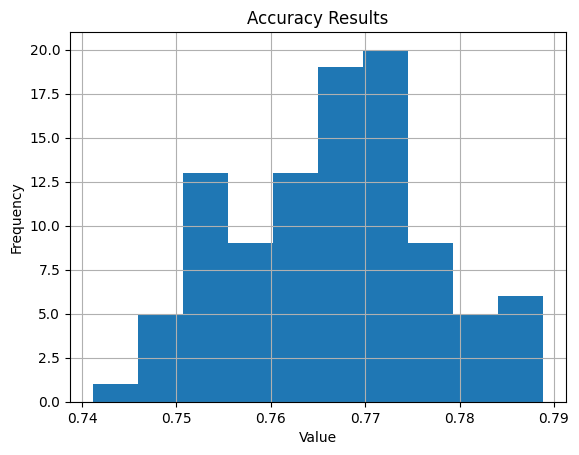

In [ ]:
pd.Series(results).hist() ;
plt.title('Accuracy Results')
plt.xlabel('Value')
plt.ylabel('Frequency')


Heres a nice graph of our accuracy tests!  Looks pretty normal to me.

### Confusion Matrix and Classification Report

Text(0.5, 1.0, 'Transaction Success Confusion Matrix')

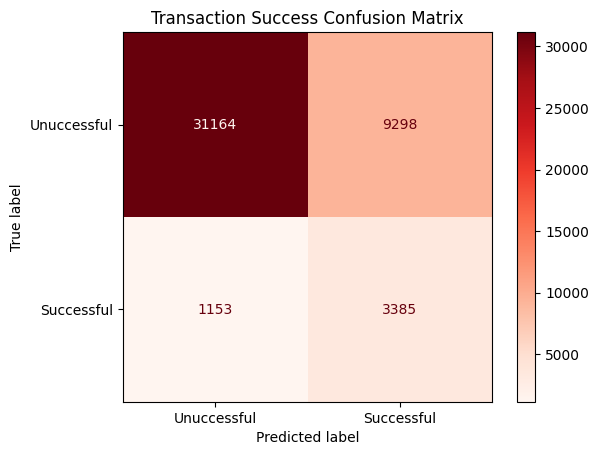

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

cmd = ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                        cmap = "Reds",
                                        display_labels=["Unuccessful", "Successful"],
                                        values_format='d')

cmd.ax_.set_title("Transaction Success Confusion Matrix")


\Here we have our confusion matrix, which matches our predictions vs our test set.  We can see our model is quite accurate, overall doing a very good job at predicting the correct values.

In [ ]:
print(classification_report(y_test, y_pred, target_names=["Unsuccessful", "Successful"]))

              precision    recall  f1-score   support

Unsuccessful       0.96      0.77      0.86     40462
  Successful       0.27      0.75      0.39      4538

    accuracy                           0.77     45000
   macro avg       0.62      0.76      0.62     45000
weighted avg       0.89      0.77      0.81     45000



While overall the predicting model does well, we have so many more unsuccessful transactions that successful ones aren't reported very precisely!  Recall is even worse, showing that many of the successful sales are predicted as unsuccessful which is absolutely not ideal.

### Data Sampling

We now see that having so many more unsuccesses than successes is not helpful when successes are what we are trying to predict, so some adjustments are needed!  The sample method is useful and we can use it on the unsuccessful transactions dataframe.

In [ ]:
trimmed_unsucc = unsucc_trans.sample(len(succ_trans), random_state = 42)
print(f"{len(trimmed_unsucc)}, {len(succ_trans)}")

18040, 18040


The sample() function takes the size of the desired sample as the input, so we just use the length of the successful array to make the two match in size!  Now we can concatenate these arrays together to make a more balanced dataset

### Balanced x and y

In [ ]:
bal_df = pd.concat([trimmed_unsucc, succ_trans])
bal_df = bal_df.sample(frac=1, random_state = 42).reset_index(drop = True)
bal_df

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
0,0.0,9.0090,17.3210,12.2977,-3.9248,-5.9224,6.8092,13.3192,2.7030,11.2656,...,10.2930,3.7816,6.7116,22.8630,14.0069,2.5795,0.6406,7.5008,-20.0641,14.1196
1,1.0,8.3040,18.0022,8.8494,2.7457,-6.9844,6.7640,12.3436,2.5079,13.3218,...,11.1943,3.9634,8.7035,5.3933,7.9629,2.1822,-1.2041,7.3183,2.1054,14.3485
2,1.0,7.1729,14.6797,5.8230,-0.3781,-4.9279,6.4074,14.3937,3.4516,7.6705,...,11.4188,3.9953,7.5813,11.8664,9.3975,1.6484,0.6545,-6.5943,-8.1507,14.3064
3,1.0,3.8909,12.8501,14.7992,-0.0188,6.5466,6.8911,12.3403,2.9761,3.2171,...,11.1052,4.0287,9.4971,21.8262,12.3499,-0.2448,0.6925,-8.4882,12.0015,14.2420
4,0.0,4.6657,16.5810,7.8742,4.2134,11.0628,7.0951,5.0652,3.5259,10.1535,...,11.6863,3.6046,8.9308,19.2898,8.2890,2.6499,-0.8973,-1.7025,-11.7203,14.0458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36075,0.0,9.0871,11.8824,18.9021,-13.5720,-0.1185,7.0532,14.6823,3.0974,9.6859,...,11.8289,4.1500,6.8430,19.5700,14.1925,2.8116,2.4290,3.4945,4.0570,14.1993
36076,0.0,11.4776,17.5080,12.2932,-7.7919,3.2019,6.8659,13.1963,2.7593,6.0957,...,10.9431,4.0923,5.8876,17.6186,6.7734,3.6696,-1.7958,-2.3624,-8.5987,14.2693
36077,0.0,6.9687,8.6089,13.2376,-5.5290,5.9935,6.9045,4.4286,2.3469,12.4680,...,11.5888,4.0590,7.6554,8.6888,11.5019,1.4546,-2.8531,-3.0190,-5.4390,14.0951
36078,0.0,3.2039,15.2645,10.6719,-9.9065,8.6618,6.9643,-6.4667,3.1961,16.4914,...,11.2860,3.8675,7.0926,12.8189,10.9216,-0.8655,-1.8979,-11.6902,-13.6676,14.1968


The sample() method can have frac set to 1, indicating that 100%  of rows are kept; this effectively gives us an in place shuffle!  But we don't want the indexes to be shuffled, so we use reset_index() and set drop = True to remove the column of old indexes that would normally be created

In [ ]:
bal_y = bal_df["target"]
bal_x = bal_df.drop(["target"], axis = 1)



### Training and Cross Cross Validation

In [ ]:
# Time for some more model fitting!
model.fit(bal_x, bal_y) ;
bal_pred_y = model.predict(bal_x)
bal_accuracy = metrics.accuracy_score(bal_y,bal_pred_y) * 100
bal_accuracy

75.48780487804878

In [ ]:
results = cross_val_score(model, bal_x, bal_y, scoring='accuracy', cv = 10)
bal_acc = results.mean() * 100
bal_acc


np.float64(75.31873614190687)

You may notice that now overall the model is less accurate with this more balanced dataset, but that doesn't necessarily make it worse...

In [ ]:
print(classification_report(bal_y, bal_pred_y, target_names=["Unsuccessful", "Successful"]))

              precision    recall  f1-score   support

Unsuccessful       0.75      0.77      0.76     18040
  Successful       0.76      0.74      0.75     18040

    accuracy                           0.75     36080
   macro avg       0.76      0.75      0.75     36080
weighted avg       0.76      0.75      0.75     36080



Here's a few metrics for this adjusted model!  Some interesting findings are visible...

## Data Visualization/Communication of Results


A visual is a great way to inspect the results of the data and is the best way to make the data palatable to investors

### Overall confusion matrix and classification results

Now we can present our results!  Since we are comparing two different graphs, it's a good idea to use normalization. The plt subplots makes sure our CMDs are side by side and tight_layout() prevents anything from overlapping.  The CMD paramater of im_kw allows us to set the range of the color, making sure its consistent between out two graphs!

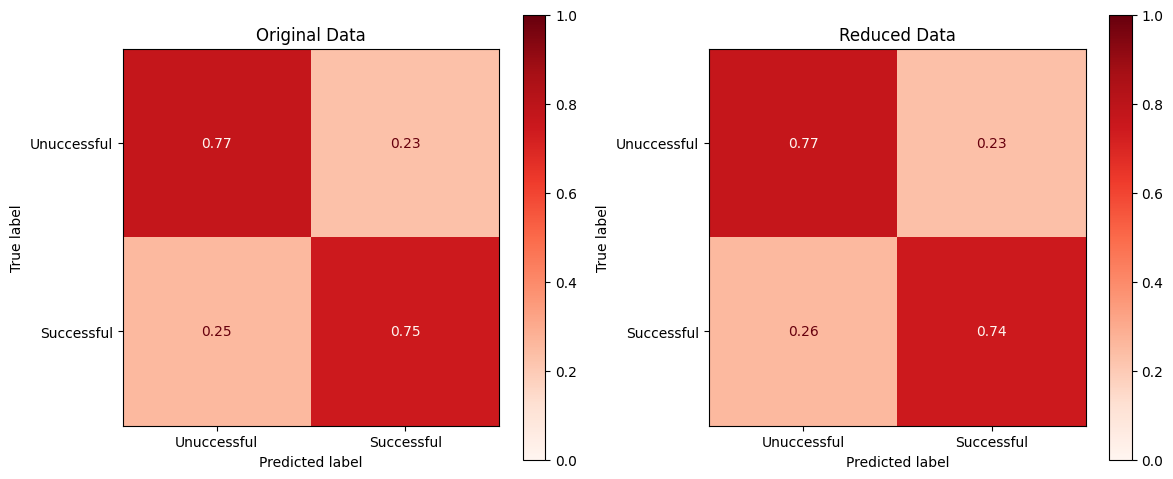

In [ ]:
# This is the figure that will store both our CMDs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# CMD for original data
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                        cmap = "Reds",
                                        normalize = 'true',
                                        display_labels=["Unuccessful", "Successful"],
                                        ax=ax1,
                                        im_kw={'vmin': 0, 'vmax': 1})


ax1.set_title("Original Data")

# CMD for balanced data
ConfusionMatrixDisplay.from_predictions(bal_y, bal_pred_y,
                                        cmap = "Reds",
                                        normalize = 'true',
                                        display_labels=["Unuccessful", "Successful"],
                                        ax=ax2,
                                        im_kw={'vmin': 0, 'vmax': 1})

ax2.set_title("Reduced Data")

# Makes sure our plots don't overlap!
plt.tight_layout()


Looking at our graphs, on paper the original data is better at prediction but remember that we are trying to predict **successful** transactions, and in that aspect our Reduced Data clearly performs far better!  In fact, 74% of the success predictions on our balanced data are correct while in the original data it's **23%**.   
Lets see what our classification reports show use as well.

### Communication of results

In [ ]:
print(f"Original Data: \n{classification_report(y_test, y_pred, target_names=["Unsuccessful", "Successful"])}")
print(f"Reduced Data: \n{classification_report(bal_y, bal_pred_y, target_names=["Unsuccessful", "Successful"])}")

Original Data: 
              precision    recall  f1-score   support

Unsuccessful       0.96      0.77      0.86     40462
  Successful       0.27      0.75      0.39      4538

    accuracy                           0.77     45000
   macro avg       0.62      0.76      0.62     45000
weighted avg       0.89      0.77      0.81     45000

Reduced Data: 
              precision    recall  f1-score   support

Unsuccessful       0.75      0.77      0.76     18040
  Successful       0.76      0.74      0.75     18040

    accuracy                           0.75     36080
   macro avg       0.76      0.75      0.75     36080
weighted avg       0.76      0.75      0.75     36080



Recall is the stat we want to focus on since it looks at how many transactions were predicted as "successful" over all "successfull" predictions, and we can see that it's far higher on our reduced dataset!  The f1 score is also FAR worse on our original dataset, as a result of low balance.

## Conclusion

From this testing, we see the important of knowing what you are looking for from a dataset and how much data balancing can impact results.

Though the original dataset seemed better on paper, most of its accuracy came from predicting unsuccessful transactions while successful ones were corrected predicted at a rate of **23%**!  While our reduced dataset had less overall accuracy, it predicted successful transactions at a rate of **74%** making it far more desirable for business purposes.

F1 score is another important metric because it takes into account how good the model is at predicting both successful and unsuccessful transactions, and we see with the original dataset it's **34%** while with out reduced one it's **75%**.  
This overall shows the importance of distinguishing the different metrics and having awareness of which ones best suit our purposes.
